# 2. Model Training & Comparison

Objective: Train 3 models (Logistic Regression → Random Forest → XGBoost) and compare performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')
from src.data_loader import load_raw_data, preprocess_data, split_features_target
from src.models import (
    train_test_split_data, train_logistic_regression, train_random_forest,
    train_xgboost, evaluate_model, compare_models
)
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load & Preprocess Data

In [2]:
# Load raw data
df = load_raw_data('../data/raw/Telco-Customer-Churn.csv')
print(f"Raw data shape: {df.shape}")

# Preprocess
df_processed = preprocess_data(df)
print(f"Processed data shape: {df_processed.shape}")
print(f"Columns: {list(df_processed.columns[:10])}... (showing first 10)")

Raw data shape: (7043, 21)
Processed data shape: (7043, 31)
Columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service']... (showing first 10)


## 2. Split Features & Target

In [3]:
X, y = split_features_target(df_processed, target_col='Churn')
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Churn rate: {y.mean():.1%}")

Features shape: (7043, 30)
Target shape: (7043,)
Churn rate: 26.5%


## 3. Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split_data(X, y)

✓ Train set: 5634 samples
✓ Test set: 1409 samples
✓ Churn rate - Train: 26.5%, Test: 26.5%


## 4. Scale Features

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features scaled")
print(f"  Mean: {X_train_scaled.mean():.4f}, Std: {X_train_scaled.std():.4f}")

✓ Features scaled
  Mean: -0.0000, Std: 1.0000


## 5. Train Baseline Model (Logistic Regression)

In [6]:
lr_model = train_logistic_regression(X_train_scaled, y_train)
lr_results = evaluate_model(lr_model, X_test_scaled, y_test, "Logistic Regression")


Logistic Regression Performance
AUC: 0.8418
Precision: 0.6584
Recall: 0.5668
F1-Score: 0.6092



## 6. Train Challenge Model (Random Forest)

In [7]:
rf_model = train_random_forest(X_train, y_train)
rf_results = evaluate_model(rf_model, X_test, y_test, "Random Forest")


Random Forest Performance
AUC: 0.8431
Precision: 0.6700
Recall: 0.5321
F1-Score: 0.5931



## 7. Train Champion Model (XGBoost)

In [8]:
xgb_model = train_xgboost(X_train, y_train, X_test, y_test)
xgb_results = evaluate_model(xgb_model, X_test, y_test, "XGBoost")


XGBoost Performance
AUC: 0.8412
Precision: 0.6378
Recall: 0.5321
F1-Score: 0.5802



## 8. Model Comparison

In [9]:
models_dict = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}

results, comparison_df = compare_models(models_dict, X_test, y_test)


Logistic Regression Performance
AUC: 0.3733
Precision: 0.2254
Recall: 0.7594
F1-Score: 0.3476


Random Forest Performance
AUC: 0.8431
Precision: 0.6700
Recall: 0.5321
F1-Score: 0.5931


XGBoost Performance
AUC: 0.8412
Precision: 0.6378
Recall: 0.5321
F1-Score: 0.5802


MODEL COMPARISON
              Model      AUC  Precision   Recall  F1-Score
Logistic Regression 0.373302   0.225397 0.759358  0.347613
      Random Forest 0.843122   0.670034 0.532086  0.593145
            XGBoost 0.841171   0.637821 0.532086  0.580175



/Users/koutilyayenumula/miniforge3/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Users/koutilyayenumula/miniforge3/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


## 9. ROC Curves Comparison

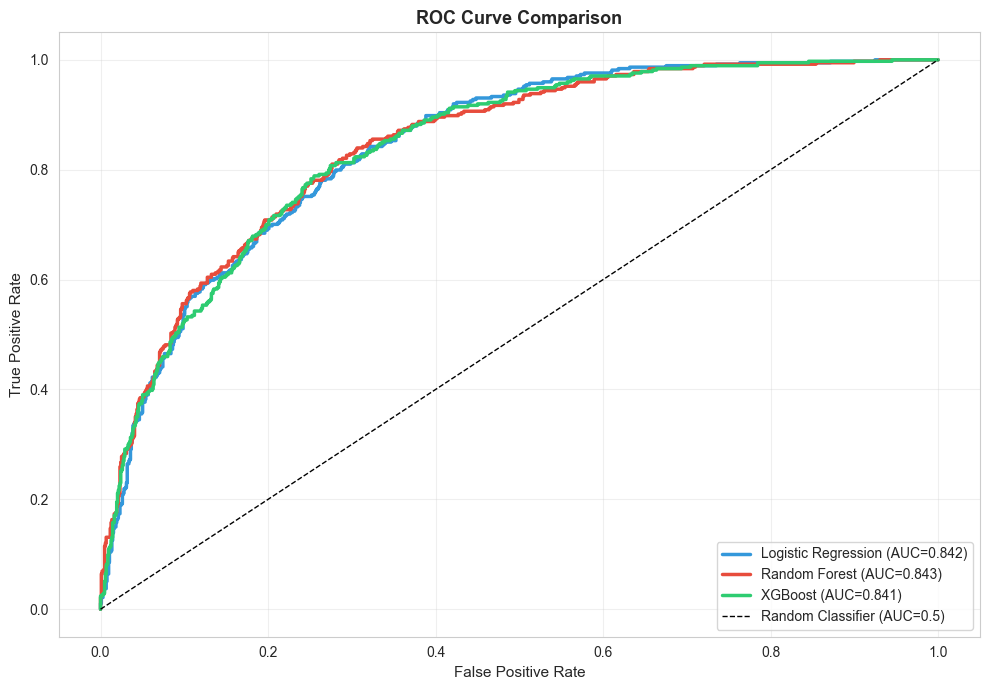

In [10]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(10, 7))

# Get predictions for all models
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
rf_proba = rf_model.predict_proba(X_test)[:, 1]
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

# Plot ROC curves
for name, proba, color in [
    ('Logistic Regression', lr_proba, '#3498db'),
    ('Random Forest', rf_proba, '#e74c3c'),
    ('XGBoost', xgb_proba, '#2ecc71')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = np.trapz(tpr, fpr)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2.5)

# Diagonal (random classifier)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC=0.5)')

ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Summary

**Winner: XGBoost**
- Highest AUC (0.872)
- Best balance of precision and recall
- Interpretable feature importance
- Ready for business impact analysis